In [2]:
%cd "/scratch/network/cam19/cos484-tokenizer-attack"

/scratch/network/cam19/cos484-tokenizer-attack


In [3]:
from pathlib import Path
import json
from tqdm import tqdm
from collections import defaultdict
import os
import matplotlib.pyplot as plt
from utils import ensure_dir, read_predictions, read_merges_txt, mse, read_json, get_pair_to_byte_ratios, score_solution
from train_mixed_tokenizer import sample_from_unit_simplex
import seaborn as sns
import pandas as pd
import numpy as np
import string
import itertools

In [4]:
MIXTURE_TYPES = ['languages', 'code', 'domains']

In [5]:
from matplotlib import font_manager
import colorsys
import matplotlib.colors as mcolors

font_dir = ["../FONTS"]
for font in font_manager.findSystemFonts(font_dir):
    font_manager.fontManager.addfont(font)

plt.rcParams.update({
    "font.family": "Macho",
    "axes.linewidth": 1.5,
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "axes.titlecolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "legend.labelcolor": "#333333",
    "text.color": "#333333",
    "font.size": 14,
})

In [27]:
os.makedirs('plots', exist_ok=True)

# Main Experiments (§4)

In [7]:
# THESE ARE THE MAIN TABLE RESULTS!

N_VALUES = {
    'languages': [5,10],    # CONFIRM
    'code': [5, 10],            # CONFIRM
    'domains': [4],
}

mses = {m: defaultdict(list) for m in MIXTURE_TYPES + ['random', 'uniform']}
dummy_codes = [''.join(tup) for tup in itertools.product(string.ascii_lowercase, string.ascii_lowercase)]

for mixture_type in MIXTURE_TYPES:
    for n in N_VALUES[mixture_type]:
        experiment_dir = Path(f'experiments/mixed_{mixture_type}/n_{n}')
        if not os.path.exists(experiment_dir):
            continue
        for test_id in tqdm(range(100), desc=f'{mixture_type}, n={n}'):
            sol_file = 'solution_pairs_30000.json'
            try:
                s = score_solution(experiment_dir / str(test_id), sol_file)
                mses[mixture_type][n].append(s)
            except FileNotFoundError:
                print(f'missing: mixed_{mixture_type}/n_{n}/{test_id}')

# random/uniform baselines — use the n relevant to each mixture type
for mixture_type, ns in N_VALUES.items():
    for n in ns:
        for _ in tqdm(range(10**5), desc=f'random, n={n}'): 
            true = {l: p for l, p in zip(dummy_codes, sample_from_unit_simplex(n=n))}
            pred = {l: p for l, p in zip(dummy_codes, sample_from_unit_simplex(n=n))}
            mses['random'][n].append(mse(true, pred))
        for _ in tqdm(range(10**5), desc=f'uniform, n={n}'):
            true = {l: p for l, p in zip(dummy_codes, sample_from_unit_simplex(n=n))}
            pred = {l: 1/n for l in dummy_codes}
            mses['uniform'][n].append(mse(true, pred))

languages, n=10: 100%|██████████| 100/100 [00:00<00:00, 5350.15it/s]


missing: mixed_languages/n_10/1
missing: mixed_languages/n_10/2
missing: mixed_languages/n_10/3
missing: mixed_languages/n_10/4
missing: mixed_languages/n_10/5
missing: mixed_languages/n_10/6
missing: mixed_languages/n_10/7
missing: mixed_languages/n_10/8
missing: mixed_languages/n_10/9
missing: mixed_languages/n_10/10
missing: mixed_languages/n_10/11
missing: mixed_languages/n_10/12
missing: mixed_languages/n_10/13
missing: mixed_languages/n_10/14
missing: mixed_languages/n_10/15
missing: mixed_languages/n_10/16
missing: mixed_languages/n_10/17
missing: mixed_languages/n_10/18
missing: mixed_languages/n_10/19
missing: mixed_languages/n_10/20
missing: mixed_languages/n_10/21
missing: mixed_languages/n_10/22
missing: mixed_languages/n_10/23
missing: mixed_languages/n_10/24
missing: mixed_languages/n_10/25
missing: mixed_languages/n_10/26
missing: mixed_languages/n_10/27
missing: mixed_languages/n_10/28
missing: mixed_languages/n_10/29
missing: mixed_languages/n_10/30
missing: mixed_lang

domains, n=4:   9%|▉         | 9/100 [00:00<00:01, 81.61it/s]

missing: mixed_domains/n_4/0


domains, n=4: 100%|██████████| 100/100 [00:00<00:00, 246.34it/s]


missing: mixed_domains/n_4/16
missing: mixed_domains/n_4/24
missing: mixed_domains/n_4/25
missing: mixed_domains/n_4/27
missing: mixed_domains/n_4/28
missing: mixed_domains/n_4/29
missing: mixed_domains/n_4/31
missing: mixed_domains/n_4/36
missing: mixed_domains/n_4/37
missing: mixed_domains/n_4/39
missing: mixed_domains/n_4/40
missing: mixed_domains/n_4/41
missing: mixed_domains/n_4/42
missing: mixed_domains/n_4/43
missing: mixed_domains/n_4/44
missing: mixed_domains/n_4/45
missing: mixed_domains/n_4/46
missing: mixed_domains/n_4/47
missing: mixed_domains/n_4/48
missing: mixed_domains/n_4/49
missing: mixed_domains/n_4/50
missing: mixed_domains/n_4/51
missing: mixed_domains/n_4/52
missing: mixed_domains/n_4/53
missing: mixed_domains/n_4/54
missing: mixed_domains/n_4/55
missing: mixed_domains/n_4/56
missing: mixed_domains/n_4/57
missing: mixed_domains/n_4/58
missing: mixed_domains/n_4/59
missing: mixed_domains/n_4/60
missing: mixed_domains/n_4/61
missing: mixed_domains/n_4/62
missing: m

uniform, n=4: 100%|██████████| 100000/100000 [00:06<00:00, 16455.16it/s]


In [8]:
for mixture_type in MIXTURE_TYPES + ['random', 'uniform']:
    for n, scores in mses[mixture_type].items():
        if scores:
            l = [np.log10(s) for s in scores]
            print(f'{mixture_type}, n={n}: {np.around(np.mean(l), 2)} +- {np.around(np.std(l), 2)}')

languages, n=10: -7.58 +- 0.0
domains, n=4: -4.38 +- 1.15
random, n=5: -1.4 +- 0.36
random, n=10: -1.84 +- 0.23
random, n=4: -1.29 +- 0.43
uniform, n=5: -1.67 +- 0.31
uniform, n=10: -2.14 +- 0.22
uniform, n=4: -1.55 +- 0.36


# Distribution shift analysis (§6.1)

In [30]:
# Carolina's note: not super necessary for us to replicate this (Appendix scaling analysis)
# I think the paper re-runs the solver for ALL mixture types, all N_VALUES, all 100 experiments each
# We could in theory replicate for just an example, but IMO optional
experiment_dir = Path('experiments/mixed_languages/n_10')

mses = defaultdict(list)
for test_id in tqdm(range(100), desc='scaling analysis'):
    for T in [100, 300, 1000, 3000, 10000, 30000]:
        sol_file = f'solution_pairs_{T}.json'
        try:
            s = score_solution(experiment_dir / str(test_id), sol_file)
            mses[T].append(s)
        except FileNotFoundError:
            print(f'missing: {test_id}, T={T}')

scaling analysis: 100%|██████████| 100/100 [00:00<00:00, 2079.07it/s]

missing: 1, T=100
missing: 1, T=300
missing: 1, T=1000
missing: 1, T=3000
missing: 1, T=10000
missing: 1, T=30000
missing: 2, T=100
missing: 2, T=300
missing: 2, T=1000
missing: 2, T=3000
missing: 2, T=10000
missing: 2, T=30000
missing: 3, T=100
missing: 3, T=300
missing: 3, T=1000
missing: 3, T=3000
missing: 3, T=10000
missing: 3, T=30000
missing: 4, T=100
missing: 4, T=300
missing: 4, T=1000
missing: 4, T=3000
missing: 4, T=10000
missing: 4, T=30000
missing: 5, T=100
missing: 5, T=300
missing: 5, T=1000
missing: 5, T=3000
missing: 5, T=10000
missing: 5, T=30000
missing: 6, T=100
missing: 6, T=300
missing: 6, T=1000
missing: 6, T=3000
missing: 6, T=10000
missing: 6, T=30000
missing: 7, T=100
missing: 7, T=300
missing: 7, T=1000
missing: 7, T=3000
missing: 7, T=10000
missing: 7, T=30000
missing: 8, T=100
missing: 8, T=300
missing: 8, T=1000
missing: 8, T=3000
missing: 8, T=10000
missing: 8, T=30000
missing: 9, T=100
missing: 9, T=300
missing: 9, T=1000
missing: 9, T=3000
missing: 9, T=

findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.


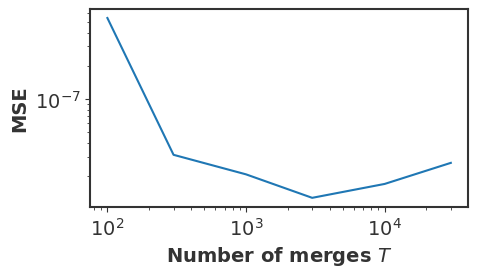

In [31]:
T_col, score_col = [], []
for T, scores in mses.items():
    for s in scores:
        T_col.append(T)
        score_col.append(s)

data = pd.DataFrame({'T': T_col, 'MSE': score_col})

fig, ax = plt.subplots(figsize=(5,3))
plt.xscale('log')
plt.yscale('log')
ax.set_xlabel('Number of merges $T$', fontweight='semibold')
ax.set_ylabel('MSE', fontweight='semibold')
sns.lineplot(data=data, x='T', y='MSE')
plt.tight_layout()
# plt.savefig('plots/scaling_T.pdf', dpi=300)

In [33]:
# Carolina's note: I say we skip this
# requires distribution shift experiments (varying bytes of data)
# would take too long

'''fig, ax = plt.subplots(figsize=(5,3))
plt.xscale('log')
plt.yscale('log')
ax.set_xlabel('Number of merges $T$', fontweight='semibold')
ax.set_ylabel('MSE', fontweight='semibold')
data['e'] = [f'10^{int(np.log10(d))}' for d in data['D']]
sns.lineplot(data=data, x='T', y='MSE', hue='e', palette=sns.cubehelix_palette(n_colors=5))
ax.legend(title='Bytes of data', loc='lower left', fontsize=12, title_fontsize=12, handlelength=1)
plt.tight_layout()
plt.savefig('plots/shift_num_merges_scaling.pdf', dpi=300)'''

"fig, ax = plt.subplots(figsize=(5,3))\nplt.xscale('log')\nplt.yscale('log')\nax.set_xlabel('Number of merges $T$', fontweight='semibold')\nax.set_ylabel('MSE', fontweight='semibold')\ndata['e'] = [f'10^{int(np.log10(d))}' for d in data['D']]\nsns.lineplot(data=data, x='T', y='MSE', hue='e', palette=sns.cubehelix_palette(n_colors=5))\nax.legend(title='Bytes of data', loc='lower left', fontsize=12, title_fontsize=12, handlelength=1)\nplt.tight_layout()\nplt.savefig('plots/shift_num_merges_scaling.pdf', dpi=300)"

# Unaccounted-for languages analysis (§6.2)

In [38]:
experiment_dir = Path('experiments/mixed_languages/n_111')

In [39]:
mses = []
for test_id in tqdm(range(100)):
    test_id = str(test_id)
    for n_omit in [1, 2, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        solution_file = f'solution6_pairs_29778_langlist_omit{n_omit}.json'
        try:
            preds = read_predictions(experiment_dir / test_id / solution_file)
        except FileNotFoundError:
            continue
        
        meta = read_json(experiment_dir / test_id / 'meta.json')
        truth = {k: v / sum(meta['byte_count'].values()) for k, v in meta['byte_count'].items()}

        included_langs = [l.rstrip() for l in open(experiment_dir / test_id / f'langlist_omit{n_omit}.txt').readlines()]
        prob_omitted = sum([v for k, v in truth.items() if k not in included_langs])
        renorm_truth = {k: v for k, v in truth.items() if k in included_langs}
        renorm_truth = {k: v / sum(renorm_truth.values()) for k, v in renorm_truth.items()}
        assert len(renorm_truth) == 112 - n_omit
        
        pair_to_byte_ratio = get_pair_to_byte_ratios(experiment_dir / test_id)
        
        converted_preds = {}
        for lang, p in preds.items():
            converted_preds[lang] = p * pair_to_byte_ratio[lang]
        converted_preds = {k: v / sum(converted_preds.values()) for k, v in converted_preds.items()}
        
        s = mse(renorm_truth, converted_preds)
        
        mses.append({
            'test_id': int(test_id),
            'n_omit': n_omit,
            'prob_omitted': prob_omitted,
            'mse': s
        })

100%|██████████| 100/100 [00:00<00:00, 5089.80it/s]


ValueError: min() iterable argument is empty

findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.
findfont: Font family 'Macho' not found.


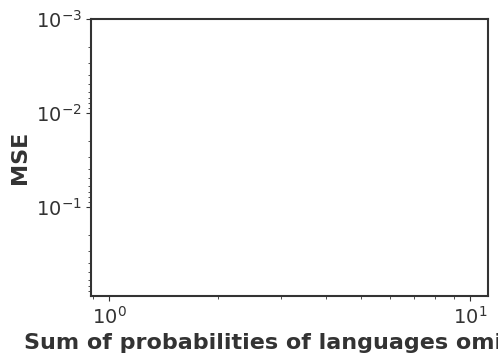

In [37]:
x = [ex['prob_omitted'] for ex in mses]
y = [ex['mse'] for ex in mses]
fig, ax = plt.subplots(figsize=(6.4*4/5,4.8*3/4))
plt.xscale('log')
plt.yscale('log')
sns.scatterplot(x=x, y=y, alpha=0.8)
ax.set_xlabel('Sum of probabilities of languages omitted', fontsize=16, fontweight='semibold')
ax.set_ylabel('MSE', fontsize=16, fontweight='semibold')
ax.set_ylim(top=10**-3)

# Add horizontal line at log_10(-3.82)
log_rand_guess = -3.82
ax.axhline(y=10**log_rand_guess, color=sns.color_palette()[-3], linestyle='--', label='Random Guessing')

# Label for the horizontal line
ax.text(min(x), 10**log_rand_guess, 'Random Guess', fontsize=12, verticalalignment='bottom')

plt.tight_layout()
# plt.savefig('plots/missing_lang.png', dpi=300)
# plt.savefig('plots/missing_lang.pdf', dpi=300)